# Requirement Setup

In [11]:
!pip install prophet
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools

In [12]:
%pip install keras-tuner

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import numpy as np
import time
import matplotlib.pyplot as plt
from datetime import datetime
from prophet.serialize import model_to_json, model_from_json

Note: you may need to restart the kernel to use updated packages.


Enable / Disable Hyperparameter Tuning

In [13]:
HYPERPARAMETER_TUNING = False

In [14]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

In [15]:
df_fifa = pd.read_csv('datasets/fifa.csv')
df_fifa.columns = ['ds', 'y_us']
df_fifa['ds'] = pd.to_datetime(df_fifa['ds'])

print(f'FIFA DATASET - Dates: {df_fifa["ds"].count()} | Total: {df_fifa["y_us"].sum()}')
df_fifa.head()

FIFA DATASET - Dates: 125300 | Total: 1352804107


,ds,y_us
0,1998-04-30 21:30:00,2
1,1998-04-30 21:31:00,11
2,1998-04-30 21:32:00,16
3,1998-04-30 21:33:00,7
4,1998-04-30 21:34:00,3


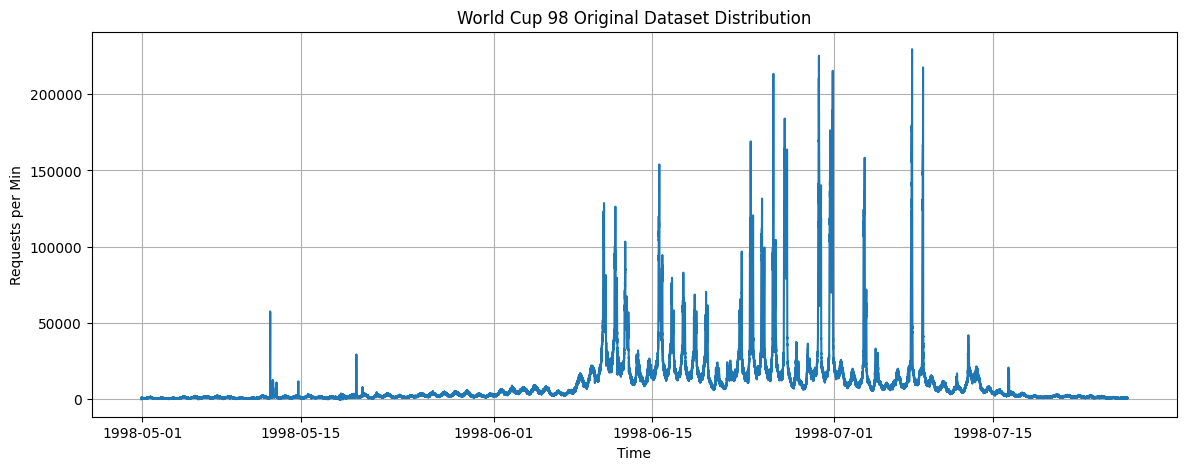

In [16]:
import os

# ensure images directory exists before saving plots
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(df_fifa['ds'], df_fifa['y_us'])
plt.title('World Cup 98 Original Dataset Distribution')
plt.xlabel('Time')
plt.ylabel('Requests per Min')
plt.grid(True)
plt.savefig("images/fifa-original.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Data Splitting & Preprocessing

1. Scaling to 0-1  
2. Split datasets as 70% training, 30% testing
3. Fill for empty data
4. Drop duplicate data

In [17]:
scaler = MinMaxScaler(feature_range=(0, 1))
df_fifa['y'] = scaler.fit_transform(df_fifa[['y_us']])

In [18]:
train_df_fifa, test_df_fifa = train_test_split(df_fifa, test_size=0.3, random_state=42, shuffle=False)

print(f'FIFA DATASET: Train Set: {train_df_fifa.shape} | Test Set: {test_df_fifa.shape}')

FIFA DATASET: Train Set: (87710, 3) | Test Set: (37590, 3)


In [19]:
train_df_fifa['y'].fillna(method='ffill', inplace=True)
train_df_fifa.drop_duplicates(subset='ds', inplace=True)

print(f'FIFA DATASET: Train Set: {train_df_fifa.shape} | Test Set: {test_df_fifa.shape}')

FIFA DATASET: Train Set: (87710, 3) | Test Set: (37590, 3)


C:\Users\dilee\AppData\Local\Temp\ipykernel_18424\130860953.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_fifa['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_18424\130860953.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_fifa['y'].fillna(method='ffill', inplace=True)


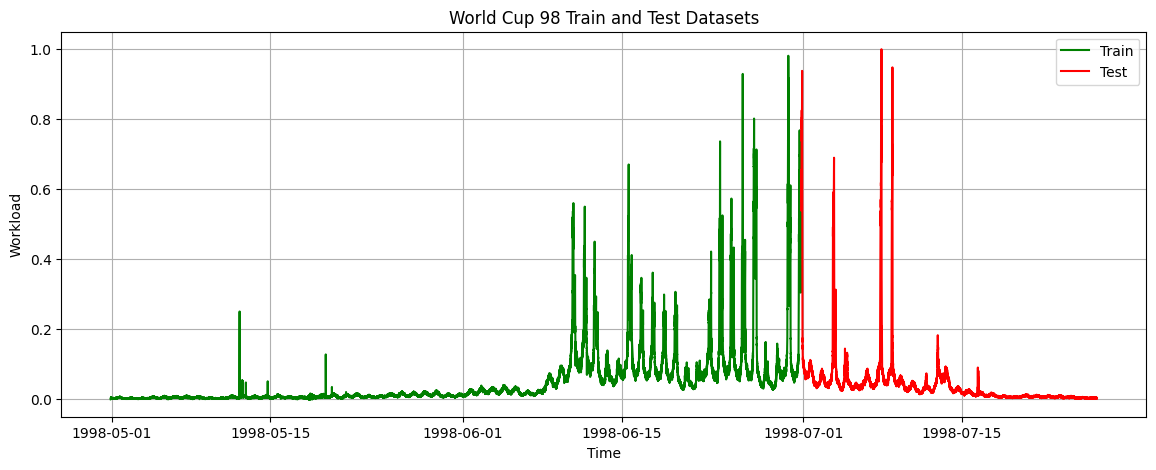

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_fifa['ds'], train_df_fifa['y'], label='Train', color='green')
plt.plot(test_df_fifa['ds'], test_df_fifa['y'], label='Test', color='red')
plt.title('World Cup 98 Train and Test Datasets')
plt.xlabel('Time')
plt.ylabel('Workload')
plt.grid(True)
plt.legend()
plt.savefig("images/fifa-train-test.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Model Training

## Seasonality Capturing with Prophet

### Train Model

In [21]:
model_one = Prophet(
    growth='flat',
    changepoint_prior_scale=5.1,
    yearly_seasonality=False,
    weekly_seasonality=20,
    daily_seasonality=50,
    seasonality_prior_scale=30
)
model_one.fit(train_df_fifa)

21:51:38 - cmdstanpy - INFO - Chain [1] start processing
21:51:47 - cmdstanpy - INFO - Chain [1] done processing


### Predict Dataset

In [23]:
# Use chunked prediction to avoid creating a huge design matrix in memory
def chunked_predict(model, df, chunk_size=5000):
	preds = []
	for i in range(0, len(df), chunk_size):
		chunk = df.iloc[i:i+chunk_size][['ds']].copy()
		preds.append(model.predict(chunk))
	return pd.concat(preds, ignore_index=True)

forecast_train_df_fifa = chunked_predict(model_one, train_df_fifa, chunk_size=5000)

start_time = time.time()
forecast_test_df_fifa = chunked_predict(model_one, test_df_fifa, chunk_size=5000)
end_time = time.time()

In [24]:
forecast_test_df_fifa_analysis = test_df_fifa.copy()
forecast_test_df_fifa_analysis = forecast_test_df_fifa_analysis.merge(forecast_test_df_fifa[['ds', 'yhat']], on='ds', how='left')

mse = mean_squared_error(forecast_test_df_fifa_analysis['y'], forecast_test_df_fifa_analysis['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(forecast_test_df_fifa_analysis['y'], forecast_test_df_fifa_analysis['yhat'])
r2 = r2_score(forecast_test_df_fifa_analysis['y'], forecast_test_df_fifa_analysis['yhat'])
model_one_time = (end_time - start_time) * 1000

print('=== Facebook Prophet Model Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R²: {r2}')
print(f'Prediction Time: {model_one_time}ms')

=== Facebook Prophet Model Metrics ===
MSE: 0.006564903242280389
RMSE: 0.08102409050572791
MAE: 0.039472109743381625
R²: 0.02076766383154871
Prediction Time: 4560.949325561523ms


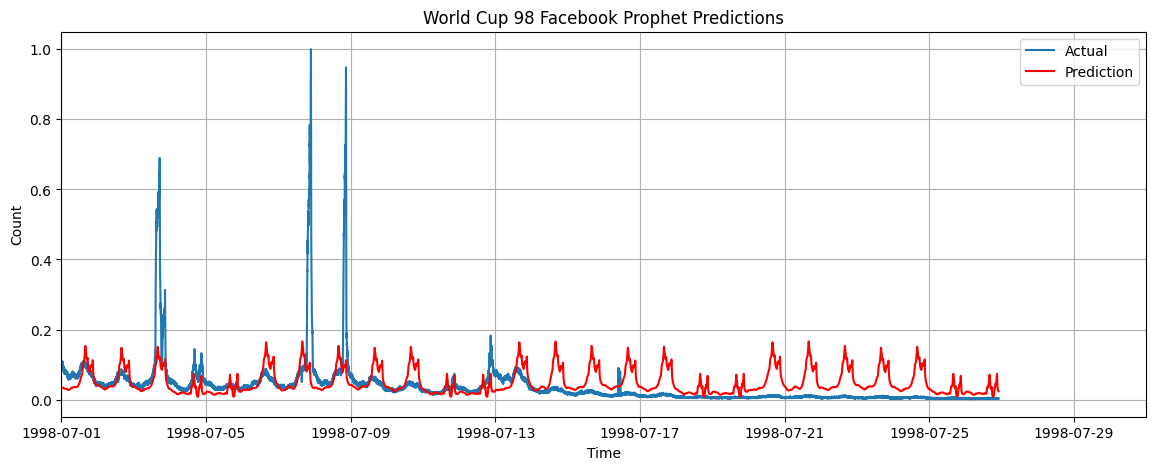

In [25]:
plt.figure(figsize=(14, 5))
# plt.plot(train_df_fifa['ds'], train_df_fifa['y'], label='Train', color='green')
plt.plot(test_df_fifa['ds'], test_df_fifa['y'], label='Actual', color='#1f77b4')
plt.plot(forecast_test_df_fifa['ds'], forecast_test_df_fifa['yhat'], label='Prediction', color='red')
plt.title('World Cup 98 Facebook Prophet Predictions')
plt.xlim(pd.to_datetime('1998-07-01'), pd.to_datetime('1998-07-31'))
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid(True)
plt.legend()
plt.savefig("images/fifa-prophet-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

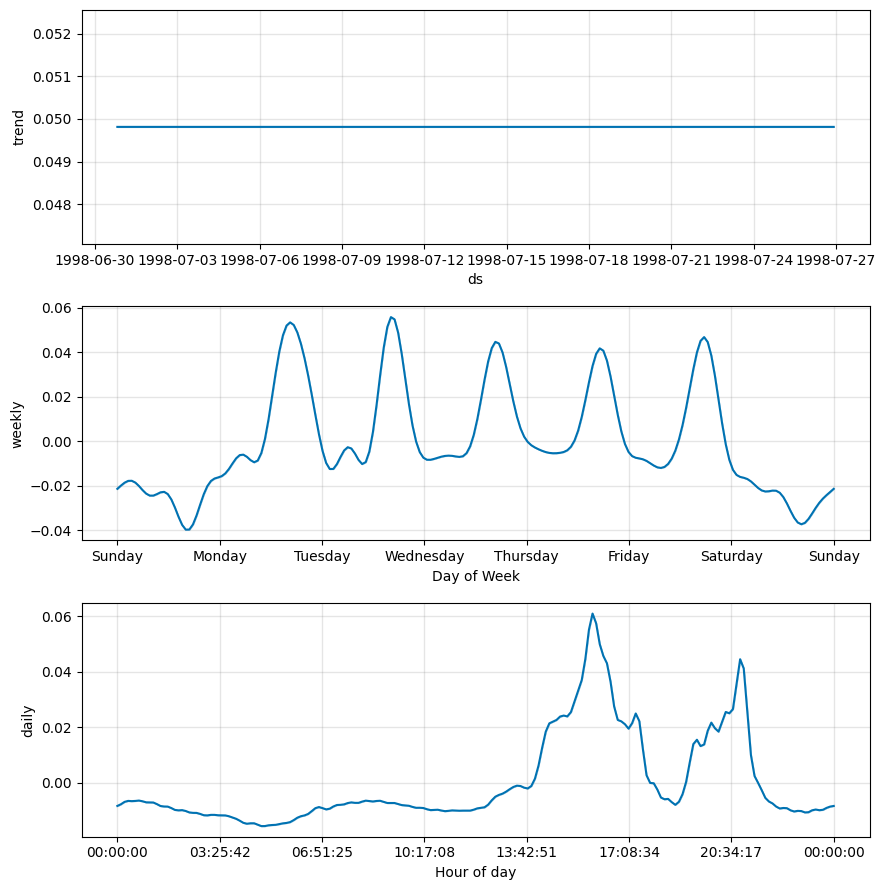

In [26]:
components_fig = model_one.plot_components(forecast_test_df_fifa);
ax_weekly = components_fig.get_axes()[1]
ax_daily = components_fig.get_axes()[2]

plt.figure(figsize=(14, 5))
plt.plot(ax_weekly.lines[0].get_xdata(), ax_weekly.lines[0].get_ydata())
plt.title('World Cup 98 Seasonality Weekly Component')
plt.xlabel(ax_weekly.get_xlabel())
plt.ylabel(ax_weekly.get_ylabel())
plt.grid(True)
plt.savefig("images/fifa-prophet-weekly.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

plt.figure(figsize=(14, 5))
plt.plot(ax_daily.lines[0].get_xdata(), ax_daily.lines[0].get_ydata())
plt.title('World Cup 98 Seasonality Daily Component')
plt.xlabel(ax_daily.get_xlabel())
plt.ylabel(ax_daily.get_ylabel())
plt.grid(True)
plt.savefig("images/fifa-prophet-daily.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

## Merge Forecasted Data

In [27]:
forecast_df_fifa = pd.concat([forecast_train_df_fifa, forecast_test_df_fifa])

## Residual Analysis

### Calculate Residuals

In [28]:
df_fifa_residual = df_fifa.merge(forecast_df_fifa[['ds', 'yhat']], on='ds', how='left')
df_fifa_residual['residual'] = df_fifa_residual['y'] - df_fifa_residual['yhat']
df_fifa_residual.head()

,ds,y_us,y,yhat,residual
0,1998-04-30 21:30:00,2,0.000004,0.059545,-0.059540
1,1998-04-30 21:31:00,11,0.000044,0.059047,-0.059004
2,1998-04-30 21:32:00,16,0.000065,0.058527,-0.058461
3,1998-04-30 21:33:00,7,0.000026,0.057985,-0.057958
4,1998-04-30 21:34:00,3,0.000009,0.057425,-0.057416


### Prepare Dataset for LSTM

In [29]:
def create_dataset(dataset, look_back):
    X, y = [], []
    dataset = np.array(dataset)
    
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

In [30]:
look_back = 1
X_fifa, y_fifa = create_dataset(df_fifa_residual[['residual']], look_back)

In [31]:
X_train_fifa, X_test_fifa, y_train_fifa, y_test_fifa = train_test_split(X_fifa, y_fifa, test_size=0.3, random_state=42, shuffle=False)

X_train_fifa = np.reshape(X_train_fifa, (X_train_fifa.shape[0], X_train_fifa.shape[1], 1))
X_test_fifa = np.reshape(X_test_fifa, (X_test_fifa.shape[0], X_test_fifa.shape[1], 1))

print(f'FIFA DATASET: Train Set: {X_train_fifa.shape} | Test Set: {X_test_fifa.shape}')

FIFA DATASET: Train Set: (87709, 1, 1) | Test Set: (37590, 1, 1)


### Model Definition

In [32]:
model_two = None

#### Early Stopping

In [33]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#### HyperParameter Tuning (If Enabled)

In [34]:
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=True, input_shape=(look_back, 1)))
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=512, step=32), return_sequences=False))
    model.add(Dense(1))
    
    model.compile(optimizer=hp.Choice('optimizer', values=['adam', 'rmsprop']), loss='mean_squared_error')
    return model

In [35]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=2,
    directory='hyperparam_tuning',
    project_name='lstm_hyperparam_tuning'
)

c:\Users\dilee\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
if HYPERPARAMETER_TUNING:
    tuner.search(X_train_fifa, y_train_fifa, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

In [37]:
if HYPERPARAMETER_TUNING:
    model_two = tuner.get_best_models(num_models=1)[0]
    model_two_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Units: {model_two_hyperparameters.get('units')}")
    print(f"Optimizer: {model_two_hyperparameters.get('optimizer')}")

#### Default Model

In [38]:
if not HYPERPARAMETER_TUNING:
    model_two = Sequential()
    model_two.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
    model_two.add(LSTM(50, return_sequences=False))
    model_two.add(Dense(1))
    model_two.compile(optimizer='adam', loss='mean_squared_error')

Print Model Summery

In [39]:
model_two.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 1, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [40]:
model_two.fit(X_train_fifa, y_train_fifa, epochs=20, batch_size=16, validation_split=0.2, callbacks=[early_stopping], verbose=1)

Epoch 1/20
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 5.8489e-05 - val_loss: 5.0781e-05
Epoch 2/20
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 1.1713e-05 - val_loss: 5.1561e-05
Epoch 3/20
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 1.1555e-05 - val_loss: 5.2643e-05
Epoch 4/20
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 1.1410e-05 - val_loss: 5.3901e-05
Epoch 5/20
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 1.1290e-05 - val_loss: 5.5209e-05
Epoch 6/20
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 1.1200e-05 - val_loss: 5.6479e-05


### Predict Dataset

In [41]:
fifa_train_predict = model_two.predict(X_train_fifa)

start_time = time.time()
fifa_test_predict = model_two.predict(X_test_fifa)
end_time = time.time()

print(f'FIFA DATASET - Prediction Size Train: {len(fifa_train_predict)} | Prediction Size Test: {len(fifa_test_predict)}')

2741/2741 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1175/1175 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
FIFA DATASET - Prediction Size Train: 87709 | Prediction Size Test: 37590


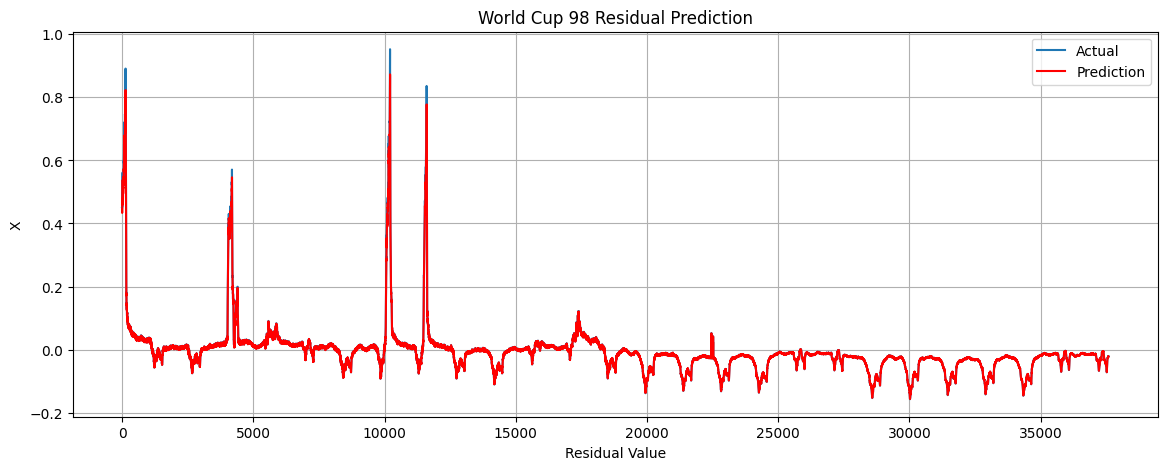

In [42]:
plt.figure(figsize=(14,5))
plt.plot(y_test_fifa, label='Actual', color='#1f77b4')
plt.plot(fifa_test_predict, label='Prediction', color='red')
plt.xlabel('Residual Value')
plt.ylabel('X')
plt.title('World Cup 98 Residual Prediction')
plt.legend()
plt.grid(True)
plt.savefig("images/fifa-lstm-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [43]:
mse = mean_squared_error(y_test_fifa, fifa_test_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_fifa, fifa_test_predict)
r2 = r2_score(y_test_fifa, fifa_test_predict)
model_two_time = (end_time - start_time) * 1000

print('=== LSTM Residual Analysis Model Metrics ===')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')
print(f'R2: {r2}')
print(f'Prediction Time: {model_two_time}ms')

=== LSTM Residual Analysis Model Metrics ===
MSE: 2.1864927349000812e-05
RMSE: 0.004675994797794456
MAE: 0.0018869940329763342
R2: 0.9966395498253122
Prediction Time: 1789.7112369537354ms


## Combine Results from Both Models

In [44]:
fifa_combine_predict = np.concatenate((fifa_train_predict, fifa_test_predict))

final_df_fifa = df_fifa_residual.copy()

final_df_fifa['residual_predict'] = np.nan
final_df_fifa['residual_predict'].iloc[0:len(fifa_combine_predict)] = fifa_combine_predict[:, 0]
print(f'FIFA DATASET: Total Output: {final_df_fifa.shape[0]} | Loss: {final_df_fifa['residual_predict'].isna().sum()}')

final_df_fifa['residual_predict'] = final_df_fifa['residual_predict'].fillna(final_df_fifa['residual'])

final_df_fifa['y_predicted'] = final_df_fifa['yhat'] + final_df_fifa['residual_predict']

final_df_fifa.head()

FIFA DATASET: Total Output: 125300 | Loss: 1


C:\Users\dilee\AppData\Local\Temp\ipykernel_18424\2727728300.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  final_df_fifa['residual_predict'].iloc[0:len(fifa_combine_predict)] = fifa_combine_predict[:, 0]
C:\Users\dilee\AppData\Local\Te

,ds,y_us,y,yhat,residual,residual_predict,y_predicted
0,1998-04-30 21:30:00,2,0.000004,0.059545,-0.059540,-0.059370,0.000175
1,1998-04-30 21:31:00,11,0.000044,0.059047,-0.059004,-0.058836,0.000211
2,1998-04-30 21:32:00,16,0.000065,0.058527,-0.058461,-0.058298,0.000229
3,1998-04-30 21:33:00,7,0.000026,0.057985,-0.057958,-0.057798,0.000186
4,1998-04-30 21:34:00,3,0.000009,0.057425,-0.057416,-0.057260,0.000165


### Extract Test Dataset Related Dataframe & Calculate Metrics

In [45]:
final_df_fifa_analysis = final_df_fifa.iloc[train_df_fifa.shape[0]:]
final_df_fifa_analysis.tail()

print(f'FIFA DATASET: Testing Output: {final_df_fifa_analysis.shape}')

FIFA DATASET: Testing Output: (37590, 7)


In [46]:
mse = mean_squared_error(final_df_fifa_analysis['y'], final_df_fifa_analysis['y_predicted'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(final_df_fifa_analysis['y'], final_df_fifa_analysis['y_predicted'])
r2 = r2_score(final_df_fifa_analysis['y'], final_df_fifa_analysis['y_predicted'])

print('=== Hybrid Model Metrics ===')
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print(f'Prediction Time: {model_one_time + model_two_time}ms')

=== Hybrid Model Metrics ===
MSE: 0.000012
RMSE: 0.003401
MAE: 0.000643
R²: 0.998274
Prediction Time: 6350.660562515259ms


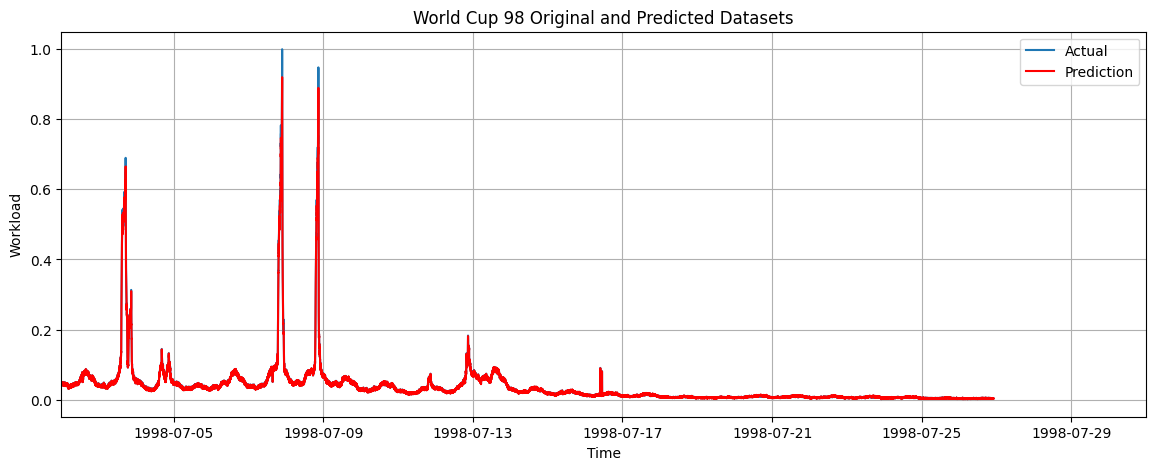

In [47]:
plt.figure(figsize=(14, 5))
# plt.plot(train_df_fifa['ds'], train_df_fifa['y'], label='Train', color='green')
plt.plot(test_df_fifa['ds'], test_df_fifa['y'], label='Actual', color='#1f77b4')
plt.plot(final_df_fifa_analysis['ds'], final_df_fifa_analysis['y_predicted'], label='Prediction', color='red')
plt.xlim(pd.to_datetime('1998-07-02'), pd.to_datetime('1998-07-31'))
plt.title('World Cup 98 Original and Predicted Datasets')
plt.xlabel('Time')
plt.ylabel('Workload')
plt.grid(True)
plt.legend()
plt.savefig("images/fifa-final-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Save Models

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f'models/fbprophet-fifa-{timestamp}.json'
with open(filename, 'w') as fout:
    fout.write(model_to_json(model_one))

filename = f'models/lstm-fifa-{timestamp}.keras' 
model_two.save(filename)